Kütüphaneler

In [25]:
import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

Veri setini yükle

In [26]:
df = pd.read_csv("data/synthetic_healthcare_50k.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Susan Sanders,39,Female,B-,Obesity,2023-04-05,Dr. Susan Park,Valley Presbyterian Hospital,Medicare,23787.02,144,Emergency,2023-04-13,Ibuprofen,Normal
1,Scott Brown,33,Male,A-,Hypertension,2020-08-31,Dr. William Foster,Riverside Community Hospital,Medicare,15700.06,466,Urgent,2020-09-03,Ibuprofen,Normal
2,Mary Barnes,41,Female,B-,Obesity,2018-02-13,Dr. Christopher Bell,Cleveland Clinic West,UnitedHealthcare,17616.28,457,Elective,2018-02-22,Paracetamol,Inconclusive
3,Timothy Gonzalez,50,Male,B-,Diabetes,2016-01-15,Dr. Linda Patel,Lakewood Memorial Hospital,Blue Cross,58131.51,409,Urgent,2016-02-08,Lipitor,Normal
4,Benjamin Reyes,32,Male,O+,Arthritis,2018-04-15,Dr. Daniel Cooper,Lakewood Memorial Hospital,Cigna,18434.37,395,Emergency,2018-05-13,Aspirin,Inconclusive


In [27]:
print(df.shape)
print(df.columns.tolist())
df.info()

(50000, 15)
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                50000 non-null  object 
 1   Age                 50000 non-null  int64  
 2   Gender              50000 non-null  object 
 3   Blood Type          50000 non-null  object 
 4   Medical Condition   50000 non-null  object 
 5   Date of Admission   50000 non-null  object 
 6   Doctor              50000 non-null  object 
 7   Hospital            50000 non-null  object 
 8   Insurance Provider  50000 non-null  object 
 9   Billing Amount      50000 non-null  float64
 10  Room Number         50000 non-null  int64  
 11  Admission Ty

In [28]:
df.isnull().sum().sort_values(ascending=False)

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [29]:
target = "Length of Stay"

df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], errors="coerce")
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], errors="coerce")

df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days
target = "Length of Stay"

drop_cols = [
    "Name",
    "Doctor",
    "Hospital",
    "Room Number",
    "Date of Admission",
    "Discharge Date"
]

drop_cols = [col for col in drop_cols if col in df.columns]
df = df.drop(columns=drop_cols)

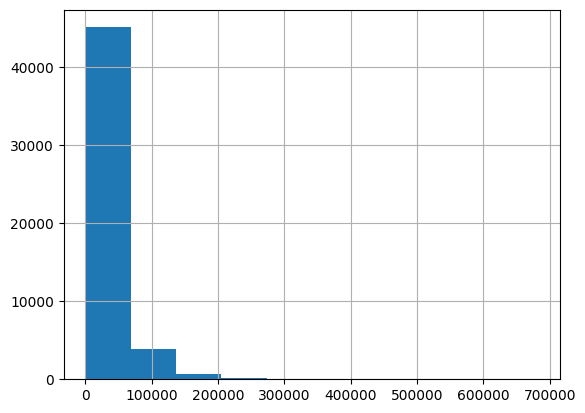

In [42]:
import matplotlib.pyplot as plt
df["Billing Amount"].hist()
plt.show()

In [31]:
df = df.dropna(subset=[target])

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 9)
y shape: (50000,)


In [32]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']
Numerical columns: ['Age', 'Billing Amount']


In [33]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [34]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(40000, 9) (10000, 9)


In [36]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10]

array([ 6.48495385,  6.83663038, 12.60193877, 28.23072641,  6.64883504,
       15.78193525, 11.89539854,  9.38964064,  6.92463916, 13.18237215])

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = {
    "MAE": round(mae, 4),
    "MSE": round(mse, 4),
    "RMSE": round(rmse, 4),
    "R2": round(r2, 4)
}

metrics

{'MAE': 5.0924, 'MSE': 49.0682, 'RMSE': 7.0049, 'R2': 0.3515}

In [38]:
os.makedirs("model", exist_ok=True)

with open("model/los_model.pkl", "wb") as f:
    pickle.dump(model, f)

model_info = {
    "target": target,
    "numerical_columns": numerical_cols,
    "categorical_columns": categorical_cols,
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "model_type": "RandomForestRegressor"
}

with open("model/model_info.pkl", "wb") as f:
    pickle.dump(model_info, f)


with open("model/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Model kaydedildi.")
print("Model info kaydedildi.")
print("Metrics kaydedildi.")
print(metrics)

Model kaydedildi.
Model info kaydedildi.
Metrics kaydedildi.
{'MAE': 5.0924, 'MSE': 49.0682, 'RMSE': 7.0049, 'R2': 0.3515}
